In [1]:
# 우도 최고점 · 로그우도 최고점 · 공식 k/n 은 같은 자리인가
import numpy as np

k, n = 7, 10                                      # 앞면 7번 / 전체 10번
p = np.linspace(0.001, 0.999, 999)                # p 후보 999개
L = p**k * (1 - p)**(n - k)                       # 우도
logL = k * np.log(p) + (n - k) * np.log(1 - p)    # 로그우도

print(f"우도 L(p) 최고점     : p = {p[np.argmax(L)]:.3f}")
print(f"로그우도 l(p) 최고점 : p = {p[np.argmax(logL)]:.3f}")
print(f"공식 k/n             : p = {k / n:.3f}")

# 관측이 2,000개로 늘면 곱셈은 어떻게 되나 (앞면 확률 0.6인 동전)
rng = np.random.default_rng(42)
probs = np.where(rng.random(2000) < 0.6, 0.6, 0.4)   # 관측 하나하나의 확률값
print()
print("관측 2,000개를 그대로 곱하면 :", np.prod(probs))
print("같은 데이터의 로그우도       :", round(float(np.sum(np.log(probs))), 1))

우도 L(p) 최고점     : p = 0.700
로그우도 l(p) 최고점 : p = 0.700
공식 k/n             : p = 0.700

관측 2,000개를 그대로 곱하면 : 0.0
같은 데이터의 로그우도       : -1348.1


In [2]:
# 실습 준비 - 패키지 설치
!pip install -q "numpy>=1.26" "pandas>=2.0" "scipy>=1.11" "matplotlib>=3.7" "seaborn>=0.13" "scikit-learn>=1.3"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from scipy.optimize import minimize
import warnings; warnings.filterwarnings("ignore")

# 한글 폰트 — Colab 이면 나눔고딕을 설치한 뒤 그 ttf 를 폰트 목록에 **직접** 등록한다.
#  설치는 디스크에 파일만 만든다. 이미 떠 있는 폰트 목록은 그 사실을 모르므로 addfont 로
#  넣어 줘야 이름이 보인다(넣지 않으면 DejaVu Sans 로 밀려 한글이 전부 □ 로 나온다).
import glob, shutil, subprocess
if shutil.which("apt-get"):
    subprocess.run(["apt-get", "-y", "-qq", "install", "fonts-nanum"], check=False)
for _p in glob.glob("/usr/share/fonts/truetype/nanum/Nanum*.ttf"):   # 설치 여부와 무관하게 한 번
    try: fm.fontManager.addfont(_p)
    except Exception: pass
try: fm._get_font.cache_clear()
except Exception: pass
installed = {f.name for f in fm.fontManager.ttflist}
FONT = next((n for n in ["Pretendard", "Apple SD Gothic Neo", "NanumGothic"] if n in installed), "DejaVu Sans")
plt.rcParams["font.family"] = FONT
plt.rcParams["axes.unicode_minus"] = FONT in {"Pretendard", "DejaVu Sans"}   # 나머지 폰트에는 U+2212 가 없다
%config InlineBackend.print_figure_kwargs = {"bbox_inches": None}   # 그림마다 폭이 깎이지 않게
plt.rcParams["figure.dpi"] = plt.rcParams["savefig.dpi"] = 150      # 폭 FIG_W x 150dpi = 1500px 고정
plt.rcParams["figure.autolayout"] = True                            # 여백은 tight_layout 이 알아서
plt.rcParams.update({"font.size": 11, "axes.titlesize": 15, "axes.labelsize": 12,
                     "legend.fontsize": 11, "figure.titlesize": 17, "font.weight": "regular",
                     "text.color": "black", "axes.labelcolor": "black", "axes.titlecolor": "black",
                     "axes.edgecolor": "#757575", "xtick.color": "#757575", "ytick.color": "#757575",
                     "xtick.labelcolor": "black", "ytick.labelcolor": "black",
                     # 위 테두리·오른쪽 테두리·격자를 걷어내 데이터만 남긴다
                     "axes.spines.top": False, "axes.spines.right": False, "axes.grid": False})

# 오늘 그림들이 함께 쓰는 색 — 우도 곡선=파랑, 강조=하늘색, 문맥=회색
COL = {"남색": "#051C2C", "파랑": "#2251FF", "하늘색": "#00A9F4",
       "회색": "#757575", "연회색": "#B3B3B3", "참값": "#757575"}
FIG_W = 10.0     # 캔버스 폭은 모두 이 값으로 고정하고 높이만 그림마다 조절한다

print("사용 폰트:", FONT,
      "| 색 팔레트 준비 완료 — 채점 셀은 LMS 가 자동으로 준비합니다")

사용 폰트: DejaVu Sans | 색 팔레트 준비 완료 — 채점 셀은 LMS 가 자동으로 준비합니다


In [1]:
# 미션 1 · 준비 — 읽고 실행만 합니다. 이 셀이 미션 1 에 쓸 변수를 직접 만듭니다
from sklearn.datasets import fetch_openml

# freMTPL2freq — 프랑스 자동차보험 계약별 사고 기록 (678,013 x 12). OpenML 에서 바로 내려받습니다
df = fetch_openml(data_id=41214, as_frame=True).frame
df["IDpol"] = df["IDpol"].astype(int)
for c in ["Area", "VehBrand", "VehGas", "Region"]:
    df[c] = df[c].astype(str).str.strip("'").astype("category")

# 받자마자 고정하는 전처리 두 규칙 — 오늘 내내 이대로 씁니다
df["ClaimNb"] = df["ClaimNb"].astype(int).clip(upper=4)   # 사고 5건 이상은 극소수라 상한 4 로 절사
df["Exposure"] = df["Exposure"].clip(upper=1.0)           # 유지 기간은 1년 상한
# 오늘 분석할 변수 — 사고를 겪었는가 아닌가
df["HasClaim"] = (df["ClaimNb"] > 0).astype(int)

y = df["HasClaim"].to_numpy(dtype=float)     # 쓸 변수 1 — 계약별 사고 유무 (0 또는 1)
n_all = int(len(y))                          # 쓸 변수 2 — 전체 계약 수 (단위 건)


def bern_nll(p):                             # 쓸 변수 3 — 베르누이의 음의 로그우도
    """p 는 0 과 1 사이 숫자 하나 또는 길이 1 배열. 최소화용이라 로그우도에 마이너스를 붙여 돌려줍니다"""
    p = float(np.atleast_1d(p)[0])
    if not 0.0 < p < 1.0:
        return 1e12                          # 범위 밖 후보에는 큰 벌점
    n_claimed = float(y.sum())
    return -(n_claimed * np.log(p) + (n_all - n_claimed) * np.log(1.0 - p))


print("행 x 열 :", df.shape, "| 결측치 총합 :", int(df.isna().sum().sum()))
print("전체 계약 수 :", f"{n_all:,}", "건")
print(df[["IDpol", "ClaimNb", "Exposure", "HasClaim", "VehPower", "Region"]].head())
print("쓸 수 있는 이름 : y (사고 유무 0/1) · n_all (전체 계약 수, 건) · bern_nll(p) (음의 로그우도)")

행 x 열 : (678013, 13) | 결측치 총합 : 0
전체 계약 수 : 678,013 건
   IDpol  ClaimNb  Exposure  HasClaim  VehPower Region
0      1        1      0.10         1         5    R82
1      3        1      0.77         1         5    R82
2      5        1      0.75         1         6    R22
3     10        1      0.09         1         7    R72
4     11        1      0.84         1         7    R72
쓸 수 있는 이름 : y (사고 유무 0/1) · n_all (전체 계약 수, 건) · bern_nll(p) (음의 로그우도)


사고를 겪은 계약수: 34060
사고 경험률: 0.050235


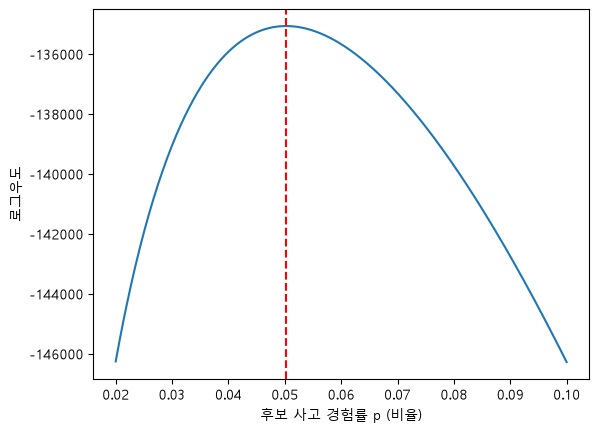

In [4]:
# 미션 1 — 프롬프트   # ai: prompt
# PROMPT 를 쓰고 → 도우미에 "위 PROMPT 대로 코드를 써 줘" → 「이 셀에 넣기」 → ▶
PROMPT = """
y, n_all, bern_nll은 이미 있으니 다시 만들지 마
사고 경험률은 bern_nll을 수치 최적화로 가장 작게 만드는 비율이고 소수 여섯자리까지 출력해
사고를 겪은 계약수는 y를 전부 더한값이야 정수야
그래프를 하나 그릴건데 가로축은 후보 사고 경험률 p 0.02 ～ 0.10, 세로축은 로그우도인 선 그래프
곡선 : 후보 p 를 촘촘히 늘어놓은 로그우도 곡선 하나

수직선 : 1번에서 찾은 p 자리에 하나

가로축 이름 : 「후보 사고 경험률 p (비율)」

세로축 이름 : 「로그우도」
"""
# --- 여기부터 AI 코드 ---
from scipy.optimize import minimize_scalar
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import matplotlib.font_manager as fm

candidates = ["Malgun Gothic", "NanumGothic", "AppleGothic"]
available = {f.name for f in fm.fontManager.ttflist}
font_name = next((c for c in candidates if c in available), None)
if font_name:
    plt.rcParams["font.family"] = font_name
plt.rcParams["axes.unicode_minus"] = False

pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 150)

k = int(y.sum())

res = minimize_scalar(bern_nll, bounds=(1e-6, 1-1e-6), method='bounded')
p_hat = res.x

print(f"사고를 겪은 계약수: {k}")
print(f"사고 경험률: {p_hat:.6f}")

p_grid = np.linspace(0.02, 0.10, 500)
loglik = [-bern_nll(p) for p in p_grid]

plt.plot(p_grid, loglik)
plt.axvline(p_hat, color='red', linestyle='--')
plt.xlabel("후보 사고 경험률 p (비율)")
plt.ylabel("로그우도")
plt.show()

In [5]:
# 미션 2 · 준비 — 읽고 실행만 합니다. 이 셀이 미션 2 에 쓸 변수를 직접 만듭니다
if "df" not in globals():                                       # 맨 위 두 셀을 실행한 뒤에는 이 미션만 따로 열어도 됩니다
    from sklearn.datasets import fetch_openml                    # (앞 미션을 이미 돌렸으면 통째로 건너뜁니다)
    df = fetch_openml(data_id=41214, as_frame=True).frame
    df["IDpol"] = df["IDpol"].astype(int)
    for c in ["Area", "VehBrand", "VehGas", "Region"]:
        df[c] = df[c].astype(str).str.strip("'").astype("category")
    df["ClaimNb"] = df["ClaimNb"].astype(int).clip(upper=4)       # 오늘 고정한 전처리 두 규칙 — 미션 1 과 같습니다
    df["Exposure"] = df["Exposure"].clip(upper=1.0)
    df["HasClaim"] = (df["ClaimNb"] > 0).astype(int)              # 오늘 분석할 변수 — 사고를 겪었는가 아닌가

# 쓸 변수 1 — 지역 x 차종 x 마력으로 가른 세그먼트 표. 한 행이 요율표의 세그먼트 하나입니다
seg3 = (df.groupby(["Region", "VehBrand", "VehPower"], observed=True)
          .agg(n=("IDpol", "size"),        # n — 그 세그먼트의 계약 수 (건)
               k=("HasClaim", "sum"),      # k — 그중 사고를 겪은 계약 수 (건)
               c=("ClaimNb", "sum"))       # c — 그 세그먼트의 사고 건수 합 (건, 오늘은 쓰지 않습니다)
          .reset_index())
seg3["p_mle"] = seg3["k"] / seg3["n"]      # p_mle — 그 세그먼트의 사고 경험률 = k / n (비율)

p_all = float(df["HasClaim"].mean())       # 쓸 변수 2 — 전체 계약(회사 전체)의 사고 경험률 (비율)


def _2se(k, n):                            # 이론 3절의 ±2SE — 표준오차 x 2
    p = k / n
    return 2 * (p * (1 - p) / n) ** 0.5


_c63 = (seg3[(seg3["n"] == 63) & (seg3["k"] == 4)]
        .sort_values(["Region", "VehBrand", "VehPower"]).iloc[0])
_r43 = df.loc[df["Region"] == "R43", "HasClaim"]

print(f"세그먼트 수 : {len(seg3):,} 개 | 계약 합 : {int(seg3['n'].sum()):,} 건"
      f" | 사고를 겪은 계약 합 : {int(seg3['k'].sum()):,} 건")
print(f"세그먼트의 계약 수 — 가장 적은 세그먼트 {int(seg3['n'].min()):,} 건 ·"
      f" 가운데 {int(seg3['n'].median()):,} 건 · 가장 많은 세그먼트 {int(seg3['n'].max()):,} 건")
print("\n이론 3절에서 본 세 행 — 계약이 줄면 ±2SE 가 어떻게 벌어지는가")
for name, k, n in [("전체 계약", int(df["HasClaim"].sum()), len(df)),
                  ("지역 R43", int(_r43.sum()), int(_r43.size)),
                  ("계약 63건 세그먼트", int(_c63["k"]), int(_c63["n"]))]:
    print(f"  {name} : 계약 {n:,}건 · 사고 경험률 {k / n:.6f} · ±2SE {_2se(k, n):.6f}")
print("\n쓸 수 있는 이름 : seg3 (n · k · c · p_mle 열) · p_all (전체 계약의 사고 경험률, 비율)")

세그먼트 수 : 2,323 개 | 계약 합 : 678,013 건 | 사고를 겪은 계약 합 : 34,060 건
세그먼트의 계약 수 — 가장 적은 세그먼트 1 건 · 가운데 41 건 · 가장 많은 세그먼트 18,042 건

이론 3절에서 본 세 행 — 계약이 줄면 ±2SE 가 어떻게 벌어지는가
  전체 계약 : 계약 678,013건 · 사고 경험률 0.050235 · ±2SE 0.000531
  지역 R43 : 계약 1,326건 · 사고 경험률 0.040724 · ±2SE 0.010856
  계약 63건 세그먼트 : 계약 63건 · 사고 경험률 0.063492 · ±2SE 0.061443

쓸 수 있는 이름 : seg3 (n · k · c · p_mle 열) · p_all (전체 계약의 사고 경험률, 비율)


계약 40건 세그먼트의 ±2SE = 0.083292 비율
±2SE 를 계산할 수 없는 세그먼트 수 = 759 개
Region VehBrand  VehPower  n  k  p_mle  표준오차
   R21      B14        14  1  0    0.0   0.0
   R11      B10         4 26  0    0.0   0.0
   R52       B6        14 18  0    0.0   0.0
   R94       B4         6 16  0    0.0   0.0
   R11       B1        13 17  0    0.0   0.0


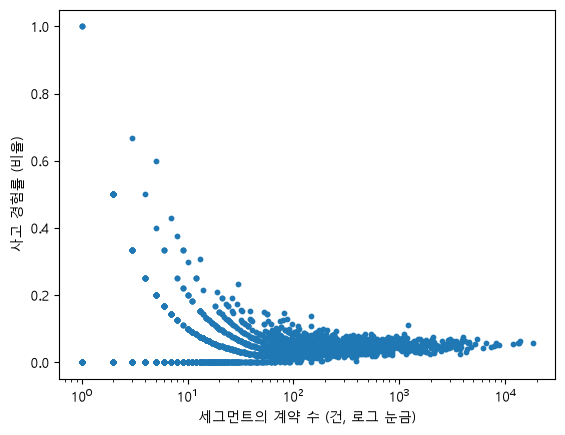

In [6]:
# 미션 2 — 프롬프트 (함정)   # ai: prompt
# 이 미션은 함정입니다 — 아래는 전임 담당자가 남긴 코드라 돌아가지만 답이 틀렸습니다.
# 어디를 어떻게 고칠지 PROMPT 에 쓰면 도우미가 구분선 아래를 다시 씁니다.
PROMPT = """
계약 40건 세그먼트의 ±2SE — 단위 비율 · 소수 여섯 자리
 ±2SE 를 재 본 그 세그먼트(계약 40건 · 사고 3건)를 n 과 k 로 직접 골라 그 행의 ±2SE 를 찍어
±2SE 를 계산할 수 없는 세그먼트 수를 결측이 아니라 다른 조건으로 직접 세
가로축은 세그먼트의 계약수, 세로축은 그 세그먼트의 사고 경험률인 산점도 그래프를 그려

점 : 세그먼트 하나에 점 하나, 모두 2,323개
▸
가로축 눈금 : 로그 눈금 — 눈금 한 단계가 10배씩 벌어집니다. matplotlib 에서는 set_xscale 한 행이에요
▸
가로축 이름 : 「세그먼트의 계약 수 (건, 로그 눈금)」
▸
세로축 이름 : 「사고 경험률 (비율)」
±2SE 가 좁은 순서로 다섯 세그먼트를 그대로 남겨
"""
# --- 여기부터 AI 코드 ---
import numpy as np
import matplotlib.pyplot as plt

seg3["표준오차"] = 2 * np.sqrt(seg3["p_mle"] * (1 - seg3["p_mle"]) / seg3["n"])

target = seg3[(seg3["n"] == 40) & (seg3["k"] == 3)]
se2_target = target["표준오차"].iloc[0]
print(f"계약 40건 세그먼트의 ±2SE = {se2_target:.6f} 비율")

n_degenerate = int(((seg3["p_mle"] == 0) | (seg3["p_mle"] == 1)).sum())
print(f"±2SE 를 계산할 수 없는 세그먼트 수 = {n_degenerate} 개")

narrow_se_first = seg3.sort_values("표준오차")
print(narrow_se_first.head(5)[["Region", "VehBrand", "VehPower", "n", "k", "p_mle", "표준오차"]].to_string(index=False))

fig, ax = plt.subplots()
ax.scatter(seg3["n"], seg3["p_mle"], s=10)
ax.set_xscale("log")
ax.set_xlabel("세그먼트의 계약 수 (건, 로그 눈금)")
ax.set_ylabel("사고 경험률 (비율)")
plt.show()

In [8]:
# 미션 3 · 준비 — 읽고 실행만 합니다. 이 셀이 미션 3 에 쓸 변수를 직접 만듭니다
if "df" not in globals():                                       # 맨 위 두 셀을 실행한 뒤에는 이 미션만 따로 열어도 됩니다
    from sklearn.datasets import fetch_openml                    # (앞 미션을 이미 돌렸으면 통째로 건너뜁니다)
    df = fetch_openml(data_id=41214, as_frame=True).frame
    df["IDpol"] = df["IDpol"].astype(int)
    for c in ["Area", "VehBrand", "VehGas", "Region"]:
        df[c] = df[c].astype(str).str.strip("'").astype("category")
    df["ClaimNb"] = df["ClaimNb"].astype(int).clip(upper=4)      # 오늘 고정한 전처리 두 규칙 — 미션 1·2 와 같습니다
    df["Exposure"] = df["Exposure"].clip(upper=1.0)
    df["HasClaim"] = (df["ClaimNb"] > 0).astype(int)             # 오늘 분석할 변수 — 사고를 겪었는가 아닌가

# 쓸 변수 1 — 세그먼트 표를 미션 2 와 같은 규칙으로 다시 셉니다 (앞에서 덧붙인 열은 남기지 않습니다)
seg3 = (df.groupby(["Region", "VehBrand", "VehPower"], observed=True)
          .agg(n=("IDpol", "size"),        # n — 그 세그먼트의 계약 수 (건)
               k=("HasClaim", "sum"),      # k — 그중 사고를 겪은 계약 수 (건)
               c=("ClaimNb", "sum"))       # c — 그 세그먼트의 사고 건수 합 (건, 오늘은 쓰지 않습니다)
          .reset_index())
seg3["p_mle"] = seg3["k"] / seg3["n"]      # p_mle — 그 세그먼트의 사고 경험률 = k / n (비율)

p_all = float(df["HasClaim"].mean())       # 쓸 변수 2 — 전체 계약의 사고 경험률 (비율)

# 쓸 변수 3 — 계약 63건·사고 4건 세그먼트 한 행. 같은 조건의 세그먼트가 둘이라 이름 순서로 하나를 고정합니다
C63 = (seg3[(seg3["n"] == 63) & (seg3["k"] == 4)]
       .sort_values(["Region", "VehBrand", "VehPower"]).iloc[0])
# 쓸 변수 4 — 계약 수가 가장 많은 세그먼트 한 행
CBIG = seg3.sort_values("n", ascending=False).iloc[0]

for name, seg_row in [("계약 63건 세그먼트", C63), ("계약 수가 가장 많은 세그먼트", CBIG)]:
    print(f"{name} : {seg_row['Region']} x {seg_row['VehBrand']} x {int(seg_row['VehPower'])}마력"
          f" | 계약 {int(seg_row['n']):,}건 · 사고를 겪은 계약 {int(seg_row['k']):,}건"
          f" · 사고 경험률 {seg_row['p_mle']:.6f} (비율)")
print(f"전체 계약의 사고 경험률 : {p_all:.6f} 비율 — 두 세그먼트 모두 이 값이"
      " 그 세그먼트의 값으로도 그럴듯한지 재 볼 자리입니다")
print(f"이론 4절의 임계값 : exp(-1.92) = {np.exp(-1.92):.6f} — 상대우도가 이 값 이상인"
      " 후보만 구간에 포함됩니다")
print("\n쓸 수 있는 이름 : seg3 (n · k · c · p_mle 열) · C63 (계약 63건·사고 4건 세그먼트 한 행)"
      " · CBIG (계약 수가 가장 많은 세그먼트 한 행) · p_all (전체 계약의 사고 경험률, 비율)")

계약 63건 세그먼트 : R22 x B3 x 4마력 | 계약 63건 · 사고를 겪은 계약 4건 · 사고 경험률 0.063492 (비율)
계약 수가 가장 많은 세그먼트 : R24 x B1 x 6마력 | 계약 18,042건 · 사고를 겪은 계약 1,023건 · 사고 경험률 0.056701 (비율)
전체 계약의 사고 경험률 : 0.050235 비율 — 두 세그먼트 모두 이 값이 그 세그먼트의 값으로도 그럴듯한지 재 볼 자리입니다
이론 4절의 임계값 : exp(-1.92) = 0.146607 — 상대우도가 이 값 이상인 후보만 구간에 포함됩니다

쓸 수 있는 이름 : seg3 (n · k · c · p_mle 열) · C63 (계약 63건·사고 4건 세그먼트 한 행) · CBIG (계약 수가 가장 많은 세그먼트 한 행) · p_all (전체 계약의 사고 경험률, 비율)


63건 세그먼트 상대우도 구간의 상한 = 0.141152 비율
전체 계약 사고 경험률의 상대우도 = 0.898101
63건 세그먼트 구간 길이 = 0.120856, 최대 세그먼트 구간 길이 = 0.006581, 18.4배 차이


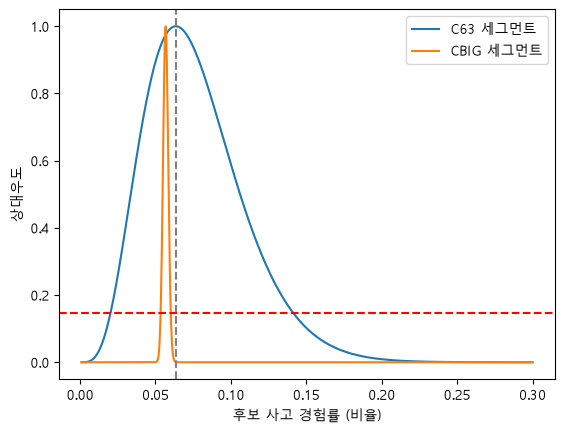

In [9]:
# 미션 3 — 프롬프트   # ai: prompt
# PROMPT 를 쓰고 → 도우미에 "위 PROMPT 대로 코드를 써 줘" → 「이 셀에 넣기」 → ▶
PROMPT = """
63건 세그먼트 상대우도 구간의 상한 — 단위 비율 · 소수 여섯 자리
▸
상대우도가 임계값 0.147 이상인 후보 가운데 가장 큰값
▸
상대우도 = 그 후보의 우도 ÷ 그 세그먼트 최댓값의 우도 · 임계값 0.147 = exp(−1.92), 곧 최댓값 우도의 약 15%
전체 계약 사고 경험률의 상대우도 소수여섯자리, p_all인 한 점의 높이
두 세그먼트의 구간 길이를 나란히 찍어 몇배차인지 봄
가로축은 후보 사고 경험률 0.001 ～ 0.30, 세로축은 상대우도인 선 그래프
▸
곡선 : 둘. C63 세그먼트 하나, CBIG 세그먼트 하나
▸
수직선 : C63 세그먼트의 사고 경험률 자리에 하나 — axvline 로 긋습니다
▸
가로선 : 임계값 0.147 자리에 하나 — axhline 로 긋습니다. 점을 늘어놓아 그으면 곡선 하나로 세어집니다
▸
가로축 이름 : 「후보 사고 경험률 (비율)」
▸
세로축 이름 : 「상대우도」
▸
곡선 둘을 구분하는 범례도 답니다
▸
후보 격자 : 격자점 1,000개 이상으로 촘촘히 놓아서 그래프도 한장 그려줘
"""
# --- 여기부터 AI 코드 ---
import numpy as np
from scipy.stats import binom
import matplotlib.pyplot as plt

n63, k63 = int(C63["n"]), int(C63["k"])
n_big, k_big = int(CBIG["n"]), int(CBIG["k"])

threshold = 0.147
p_grid = np.linspace(0.001, 0.30, 2000)

p_hat63 = k63 / n63
p_hat_big = k_big / n_big

rel_lik_63 = binom.pmf(k63, n63, p_grid) / binom.pmf(k63, n63, p_hat63)
rel_lik_big = binom.pmf(k_big, n_big, p_grid) / binom.pmf(k_big, n_big, p_hat_big)

candidates_63 = p_grid[rel_lik_63 >= threshold]
upper_63 = candidates_63.max()
lower_63 = candidates_63.min()
print(f"63건 세그먼트 상대우도 구간의 상한 = {upper_63:.6f} 비율")

rel_lik_at_pall = binom.pmf(k63, n63, p_all) / binom.pmf(k63, n63, p_hat63)
print(f"전체 계약 사고 경험률의 상대우도 = {rel_lik_at_pall:.6f}")

candidates_big = p_grid[rel_lik_big >= threshold]
width_63 = upper_63 - lower_63
width_big = candidates_big.max() - candidates_big.min()
print(f"63건 세그먼트 구간 길이 = {width_63:.6f}, 최대 세그먼트 구간 길이 = {width_big:.6f}, {width_63/width_big:.1f}배 차이")

fig, ax = plt.subplots()
ax.plot(p_grid, rel_lik_63, label="C63 세그먼트")
ax.plot(p_grid, rel_lik_big, label="CBIG 세그먼트")
ax.axvline(p_hat63, color="gray", linestyle="--")
ax.axhline(threshold, color="red", linestyle="--")
ax.set_xlabel("후보 사고 경험률 (비율)")
ax.set_ylabel("상대우도")
ax.legend()
plt.show()

In [10]:
# 과제 · 준비 — 읽고 실행만 합니다. 이 셀이 과제에 쓸 변수를 직접 만듭니다
if "df" not in globals():                                       # 맨 위 두 셀을 실행한 뒤에는 이 절만 따로 열어도 됩니다
    from sklearn.datasets import fetch_openml                    # (앞 미션을 이미 돌렸으면 통째로 건너뜁니다)
    df = fetch_openml(data_id=41214, as_frame=True).frame
    df["IDpol"] = df["IDpol"].astype(int)
    for c in ["Area", "VehBrand", "VehGas", "Region"]:
        df[c] = df[c].astype(str).str.strip("'").astype("category")
    df["ClaimNb"] = df["ClaimNb"].astype(int).clip(upper=4)      # 오늘 고정한 전처리 두 규칙 — 미션 1·2·3 과 같습니다
    df["Exposure"] = df["Exposure"].clip(upper=1.0)
    df["HasClaim"] = (df["ClaimNb"] > 0).astype(int)             # 오늘 분석할 변수 — 사고를 겪었는가 아닌가

# 쓸 변수 1 — 세그먼트 표를 미션 2·3 과 같은 규칙으로 다시 셉니다 (앞에서 덧붙인 열은 남기지 않습니다)
seg3 = (df.groupby(["Region", "VehBrand", "VehPower"], observed=True)
          .agg(n=("IDpol", "size"),        # n — 그 세그먼트의 계약 수 (건)
               k=("HasClaim", "sum"),      # k — 그중 사고를 겪은 계약 수 (건)
               c=("ClaimNb", "sum"))       # c — 그 세그먼트의 사고 건수 합 (건)
          .reset_index())
seg3["p_mle"] = seg3["k"] / seg3["n"]      # p_mle — 그 세그먼트의 사고 경험률 = k / n (비율)

p_all = float(df["HasClaim"].mean())       # 쓸 변수 2 — 전체 계약의 사고 경험률 (비율) = 판정 기준값

unmeasurable_segs = int(((seg3["k"] == 0) | (seg3["k"] == seg3["n"])).sum())
print(f"세그먼트 {len(seg3):,}개 | 컬럼 {list(seg3.columns)}")
print(f"판정 기준값 — 전체 계약의 사고 경험률 p_all = {p_all:.6f} 비율")
print(f"±2SE 를 계산할 수 없는 세그먼트 = {unmeasurable_segs} 개 — 미션 2 에서 구분한 그 세그먼트들입니다")
print(f"세그먼트의 계약 수 : 가장 적은 세그먼트 {int(seg3['n'].min()):,}건"
      f" · 가운뎃값 {int(seg3['n'].median()):,}건"
      f" · 가장 많은 세그먼트 {int(seg3['n'].max()):,}건")
print(f"전체 계약 {int(seg3['n'].sum()):,}건 — 세그먼트의 계약 수를 모두 더한 값입니다")
print("\n쓸 수 있는 이름 : df (ClaimNb · HasClaim 열) · seg3 (n · k · c · p_mle 열)"
      " · p_all (전체 계약의 사고 경험률, 비율)")

세그먼트 2,323개 | 컬럼 ['Region', 'VehBrand', 'VehPower', 'n', 'k', 'c', 'p_mle']
판정 기준값 — 전체 계약의 사고 경험률 p_all = 0.050235 비율
±2SE 를 계산할 수 없는 세그먼트 = 759 개 — 미션 2 에서 구분한 그 세그먼트들입니다
세그먼트의 계약 수 : 가장 적은 세그먼트 1건 · 가운뎃값 41건 · 가장 많은 세그먼트 18,042건
전체 계약 678,013건 — 세그먼트의 계약 수를 모두 더한 값입니다

쓸 수 있는 이름 : df (ClaimNb · HasClaim 열) · seg3 (n · k · c · p_mle 열) · p_all (전체 계약의 사고 경험률, 비율)


그대로 사용 세그먼트 수 = 960 개
재검토·계산 불가 세그먼트에 속한 계약 수 = 28491 건
재검토 세그먼트 중 계약 수가 가장 많은 세그먼트의 계약 수 = 147 건
계약당 사고 건수 = 0.053179 건/계약


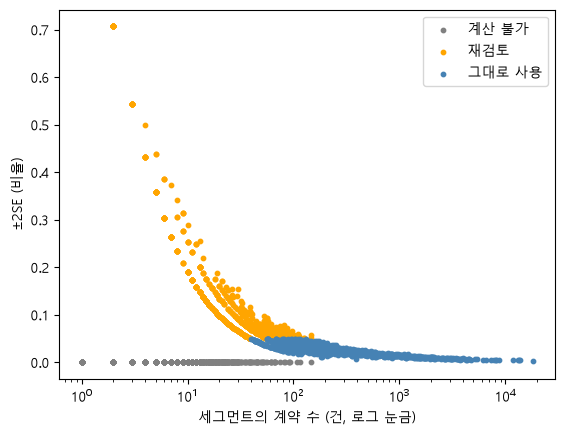

In [11]:
# 과제 — 프롬프트   # ai: prompt
# PROMPT 를 쓰고 → 도우미에 "위 PROMPT 대로 코드를 써 줘" → 「이 셀에 넣기」 → ▶
PROMPT = """
판정 열 하나 — 세그먼트마다 셋 중 하나를 적어 seg3 의 열로 남깁니다
▸
「계산 불가」 : 사고가 0건이거나 계약 전부가 사고를 겪은 세그먼트
▸
「재검토」 : 남은 세그먼트 중 ±2SE 가 p_all 보다 넓은 세그먼트
▸
「그대로 사용」 : 나머지 세그먼트
그대로 사용 세그먼트 수 — 단위 개 · 정수
재검토·계산 불가 세그먼트에 속한 계약 수 — 단위 건 · 정수
▸
세그먼트 수가 아니라 그 세그먼트들의 n 을 더한 값입니다
재검토 세그먼트 중 계약 수가 가장 많은 세그먼트의 계약 수 — 단위 건 · 정수
계약당 사고 건수 — 단위 건/계약 · 소수 여섯 자리
▸
이 값만 0/1 변수가 아닙니다. 사고 유무가 아니라 사고 건수 열의 평균이에요
그래프 한 장 — 가로축은 세그먼트의 계약 수, 세로축은 그 세그먼트의 ±2SE 인 산점도
▸
점 : 세그먼트 하나에 점 하나, 모두 2,323개
▸
가로축 눈금 : 로그 눈금
▸
색 : 판정 셋을 색으로 구분하고 범례를 답니다
▸
가로축 이름 : 「세그먼트의 계약 수 (건, 로그 눈금)」
▸
세로축 이름 : 「±2SE (비율)」
고정할 이름 — df · seg3 · p_all 은 이미 있으니 다시 만들지 마
"""
# --- 여기부터 AI 코드 ---
import numpy as np
import matplotlib.pyplot as plt

seg3["표준오차"] = 2 * np.sqrt(seg3["p_mle"] * (1 - seg3["p_mle"]) / seg3["n"])

def 판정(row):
    if row["k"] == 0 or row["k"] == row["n"]:
        return "계산 불가"
    elif row["표준오차"] > p_all:
        return "재검토"
    else:
        return "그대로 사용"

seg3["판정"] = seg3.apply(판정, axis=1)

n_ok = int((seg3["판정"] == "그대로 사용").sum())
print(f"그대로 사용 세그먼트 수 = {n_ok} 개")

n_flagged = int(seg3.loc[seg3["판정"] != "그대로 사용", "n"].sum())
print(f"재검토·계산 불가 세그먼트에 속한 계약 수 = {n_flagged} 건")

recheck = seg3[seg3["판정"] == "재검토"]
max_n_recheck = int(recheck["n"].max())
print(f"재검토 세그먼트 중 계약 수가 가장 많은 세그먼트의 계약 수 = {max_n_recheck} 건")

claims_per_contract = df["ClaimNb"].mean()
print(f"계약당 사고 건수 = {claims_per_contract:.6f} 건/계약")

fig, ax = plt.subplots()
colors = {"계산 불가": "gray", "재검토": "orange", "그대로 사용": "steelblue"}
for label, color in colors.items():
    sub = seg3[seg3["판정"] == label]
    ax.scatter(sub["n"], sub["표준오차"], s=10, color=color, label=label)
ax.set_xscale("log")
ax.set_xlabel("세그먼트의 계약 수 (건, 로그 눈금)")
ax.set_ylabel("±2SE (비율)")
ax.legend()
plt.show()

결론: 그대로 쓸 세그먼트는 960 개이고, 사람이 다시 볼 세그먼트는 28,491 개입니다.

위험: 147 — 다시 볼 세그먼트에 속한 계약과 그 계약에 무엇을 적을지 한 문장

코드가 답을 만드는 방식: 0.053179 — ±2SE 하나로 어느 기준선을 그었는지 한 문장